# KG list creation

Creating the file that will be looped over to check for child-parent relatins in predictions during training and post-hoc, as well as visualisations.

In [ ]:
import os
import networkx as nx
from networkx.readwrite import json_graph
import json
import csv
import numpy as np
import pandas as pd
import re
import scipy.io

## Creating full knowledge graph .json file

entity_tem.json contains the entity names and superclass connections, while compound_tem.json contains the inclusion and exclusion-relations.

In [ ]:
#retrieving all the edges for inspection
import json

with open(r"\data\mimic_iv_ecg\labeler\entity_tem.json") as f: #adjust to path
    templates = json.load(f)

edges = []
for entity in templates:
    name = entity["name"]
    sup = entity.get("sup", [])
    if isinstance(sup, str):
        sup = [sup]
    for parent in sup:
        edges.append((name, parent))

print(edges)

In [ ]:
#redirecting to the right directory
base_dir = os.path.join(os.getcwd(), "..", "data", "mimic_iv_ecg", "labeler")

#loading both files
with open(os.path.join(base_dir, "entity_tem.json")) as f:
    entity_templates = json.load(f)

with open(os.path.join(base_dir, "compound_tem.json")) as f:
    compound_templates = json.load(f)

#build graph
G = nx.DiGraph()

#getting the is-a edgeds
for entity in entity_templates:
    name = entity["name"]
    sup = entity.get("sup", [])
    if isinstance(sup, str):
        sup = [sup]
    for parent in sup:
        G.add_edge(name, parent, relation="is-a")

#requires + excludes edges from compound_tem.json
for compound in compound_templates:
    name = compound["entity"]
    for inc in compound.get("including", []):
        G.add_edge(name, inc["tem"], relation="requires")
    for exc in compound.get("excluding", []):
        G.add_edge(name, exc["tem"], relation="excludes")

#checking results
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print("\nSample edges:")
for child, relatoin, parent in list(G.edges(data=True))[:10]:
    print(f"  {child} --{relation['relation']}--> {parent}")

#saving
output_path = os.path.join(os.getcwd(), "..", "data", "mimic_iv_ecg", "knowledge_graph.json")
with open(output_path, "w") as f:
    json.dump(json_graph.node_link_data(G), f, indent=2)

print(f"\nSaved to {output_path}")

In [ ]:
#saving it in a more readable format
csv_path = os.path.join(os.getcwd(), "..", "data", "mimic_iv_ecg", "knowledge_graph_edges.csv")
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["source", "relation", "target"])
    for u, v, d in G.edges(data=True):
        writer.writerow([u, d["relation"], v])

print(f"Saved edge list to {csv_path}")

In [ ]:
#checkng number of requires relations (very low)
for child, relatoin, parent in G.edges(data=True):
    if relation["relation"] == "requires":
        print(f"  {child} --requires--> {parent}")

## Creating the KG subset with is-a edges

In [ ]:
#loading the kg json

with open(r'C:\Users\noors\University\thesis\ecg-thesis\data\mimic_iv_ecg\knowledge_graph.json', 'r') as f:
    d = json.load(f)

H = nx.node_link_graph(d, edges="edges")

In [ ]:
print(H)
#is consistent

DiGraph with 303 nodes and 355 edges


In [ ]:
#checks all the connections in the graph
for u, v, data in H.edges(data=True):
    print(f"{u} -> {v}: {data}")

Normal electrocardiogram -> Electrocardiogram: {'relation': 'is-a'}
Abnormal electrocardiogram -> Electrocardiogram: {'relation': 'is-a'}
Borderline electrocardiogram -> Electrocardiogram: {'relation': 'is-a'}
Normal electrocardiogram except for rate -> Electrocardiogram: {'relation': 'is-a'}
Low heart rate -> Heart rate: {'relation': 'is-a'}
High heart rate -> Heart rate: {'relation': 'is-a'}
Poor data quality -> Difficulty interpreting: {'relation': 'is-a'}
Cannot adequately assess -> Poor data quality: {'relation': 'is-a'}
Artifact -> Poor data quality: {'relation': 'is-a'}
Lead misplacement -> Lead unsuitable for analysis: {'relation': 'is-a'}
Lead unsuitable for analysis -> Lead not used for morphology analysis: {'relation': 'is-a'}
Lead reversal -> Lead misplacement: {'relation': 'is-a'}
Lead reversal -> Cannot adequately assess: {'relation': 'is-a'}
Limb lead reversal -> Lead reversal: {'relation': 'is-a'}
Arm lead reversal -> Limb lead reversal: {'relation': 'is-a'}
Missing lea

In [14]:
#find the edges that have an is-a relation
matching_edges = [
    (u, v) for u, v, d in H.edges(data=True) 
    if d.get('relation') == 'is-a'
]

G = H.edge_subgraph(matching_edges).copy()

In [ ]:
#checking how many are left
print(G)

DiGraph with 301 nodes and 346 edges


In [ ]:
#loading and printing the labels
labels = []

with open(r'C:\Users\noors\University\thesis\ecg-thesis\data\mimic_subset\mimic-iv-ecg-diagnostic-electrocardiogram-matched-subset-1.0\labels\label_def.csv', 'r') as l:
    label_def = csv.reader(l)
    for row in label_def:
        labels.append(row[0])

print(labels)

['name', 'Poor data quality', 'Sinus rhythm', 'Premature ventricular contraction', 'Tachycardia', 'Ventricular tachycardia', 'Supraventricular tachycardia with aberrancy', 'Atrial fibrillation', 'Atrial flutter', 'Bradycardia', 'Accessory pathway conduction', 'Atrioventricular block', '1st degree atrioventricular block', 'Bifascicular block', 'Right bundle branch block', 'Left bundle branch block', 'Infarction', 'Electronic pacemaker']


In [ ]:
#checking relations and saving in csv
with open(r'C:\Users\noors\University\thesis\ecg-thesis\data\mimic_iv_ecg\kg_list.csv', 'w', newline='') as csvfile:
    relationwriter = csv.writer(csvfile)
    relationwriter.writerow(["child", "parent"])

    #for every label, check if there's another label in G that has a direct connection 
    for label1 in labels:
        for label2 in labels:
            if label2 != label1 and label1 in G and label2 in G:
                if nx.has_path(G, label1, label2):
                    print(f'{label1} is a {label2}')
                    relationwriter.writerow([f"{label1}", f"{label2}"])

Ventricular tachycardia is a Tachycardia
Atrial fibrillation is a Tachycardia
Atrial fibrillation is a Accessory pathway conduction
Atrial flutter is a Tachycardia
Atrial flutter is a Accessory pathway conduction
1st degree atrioventricular block is a Atrioventricular block


## Visual graph generation

Creating the visuals for the knowledge graphs, with diagnoses as nodes and edges representing relations

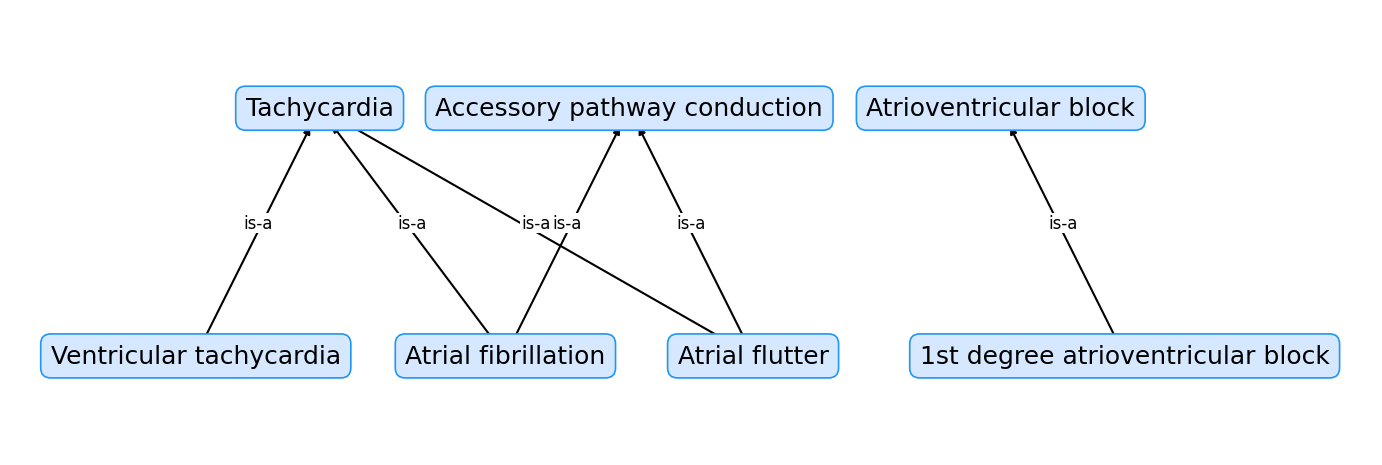

In [ ]:
import matplotlib.pyplot as plt

#PARTIALLY GENERATED CODE
#representing is-a label relations in knowledge graph

edges = [
    ("Ventricular tachycardia", "Tachycardia"),
    ("Atrial fibrillation", "Tachycardia"),
    ("Atrial fibrillation", "Accessory pathway conduction"),
    ("Atrial flutter", "Tachycardia"),
    ("Atrial flutter", "Accessory pathway conduction"),
    ("1st degree atrioventricular block", "Atrioventricular block"),
]

G = nx.DiGraph()
G.add_edges_from(edges)

pos = {
    "Tachycardia":                       (2.0, 2),
    "Accessory pathway conduction":      (4.5, 2),
    "Atrioventricular block":            (7.5, 2),
    "Ventricular tachycardia":           (1, 0),
    "Atrial fibrillation":               (3.5, 0),
    "Atrial flutter":                    (5.5, 0),
    "1st degree atrioventricular block": (8.5, 0),
}

fig, ax = plt.subplots(figsize=(14, 5))

# box half-dimensions
bw, bh = 1.1, 0.25

# draw edges manually as annotated arrows between box edges
for (child, parent) in edges:
    cx, cy = pos[child]
    px, py = pos[parent]

    ax.annotate("",
        xy=(px, py), xytext=(cx, cy),
        arrowprops=dict(
            arrowstyle="-|>",
            color="black",
            lw=1.5,
            shrinkA=15,  # pull back from child end
            shrinkB=15,  # pull back from parent end
        ))

    # is-a label at midpoint
    mx, my = (cx + px) / 2, (cy + py) / 2
    ax.text(mx, my, "is-a", fontsize=12, ha="center", va="bottom",
            color="black", bbox=dict(fc="white", ec="none", pad=1))

# draw boxes and labels on top
# draw boxes and labels on top
for node, (x, y) in pos.items():
    text_obj = ax.text(x, y, node, ha="center", va="center",
                       fontsize=18, color="black")
    text_obj.set_bbox(dict(boxstyle="round,pad=0.4",
                           facecolor="#D6E8FF", edgecolor="#2196F3", linewidth=1.2))
ax.set_xlim(-0.5, 10.5)
ax.set_ylim(-0.8, 2.8)
ax.set_aspect("equal")
ax.axis("off")
plt.tight_layout()
plt.savefig("kg_subgraph.png", dpi=150, bbox_inches="tight")
plt.show()

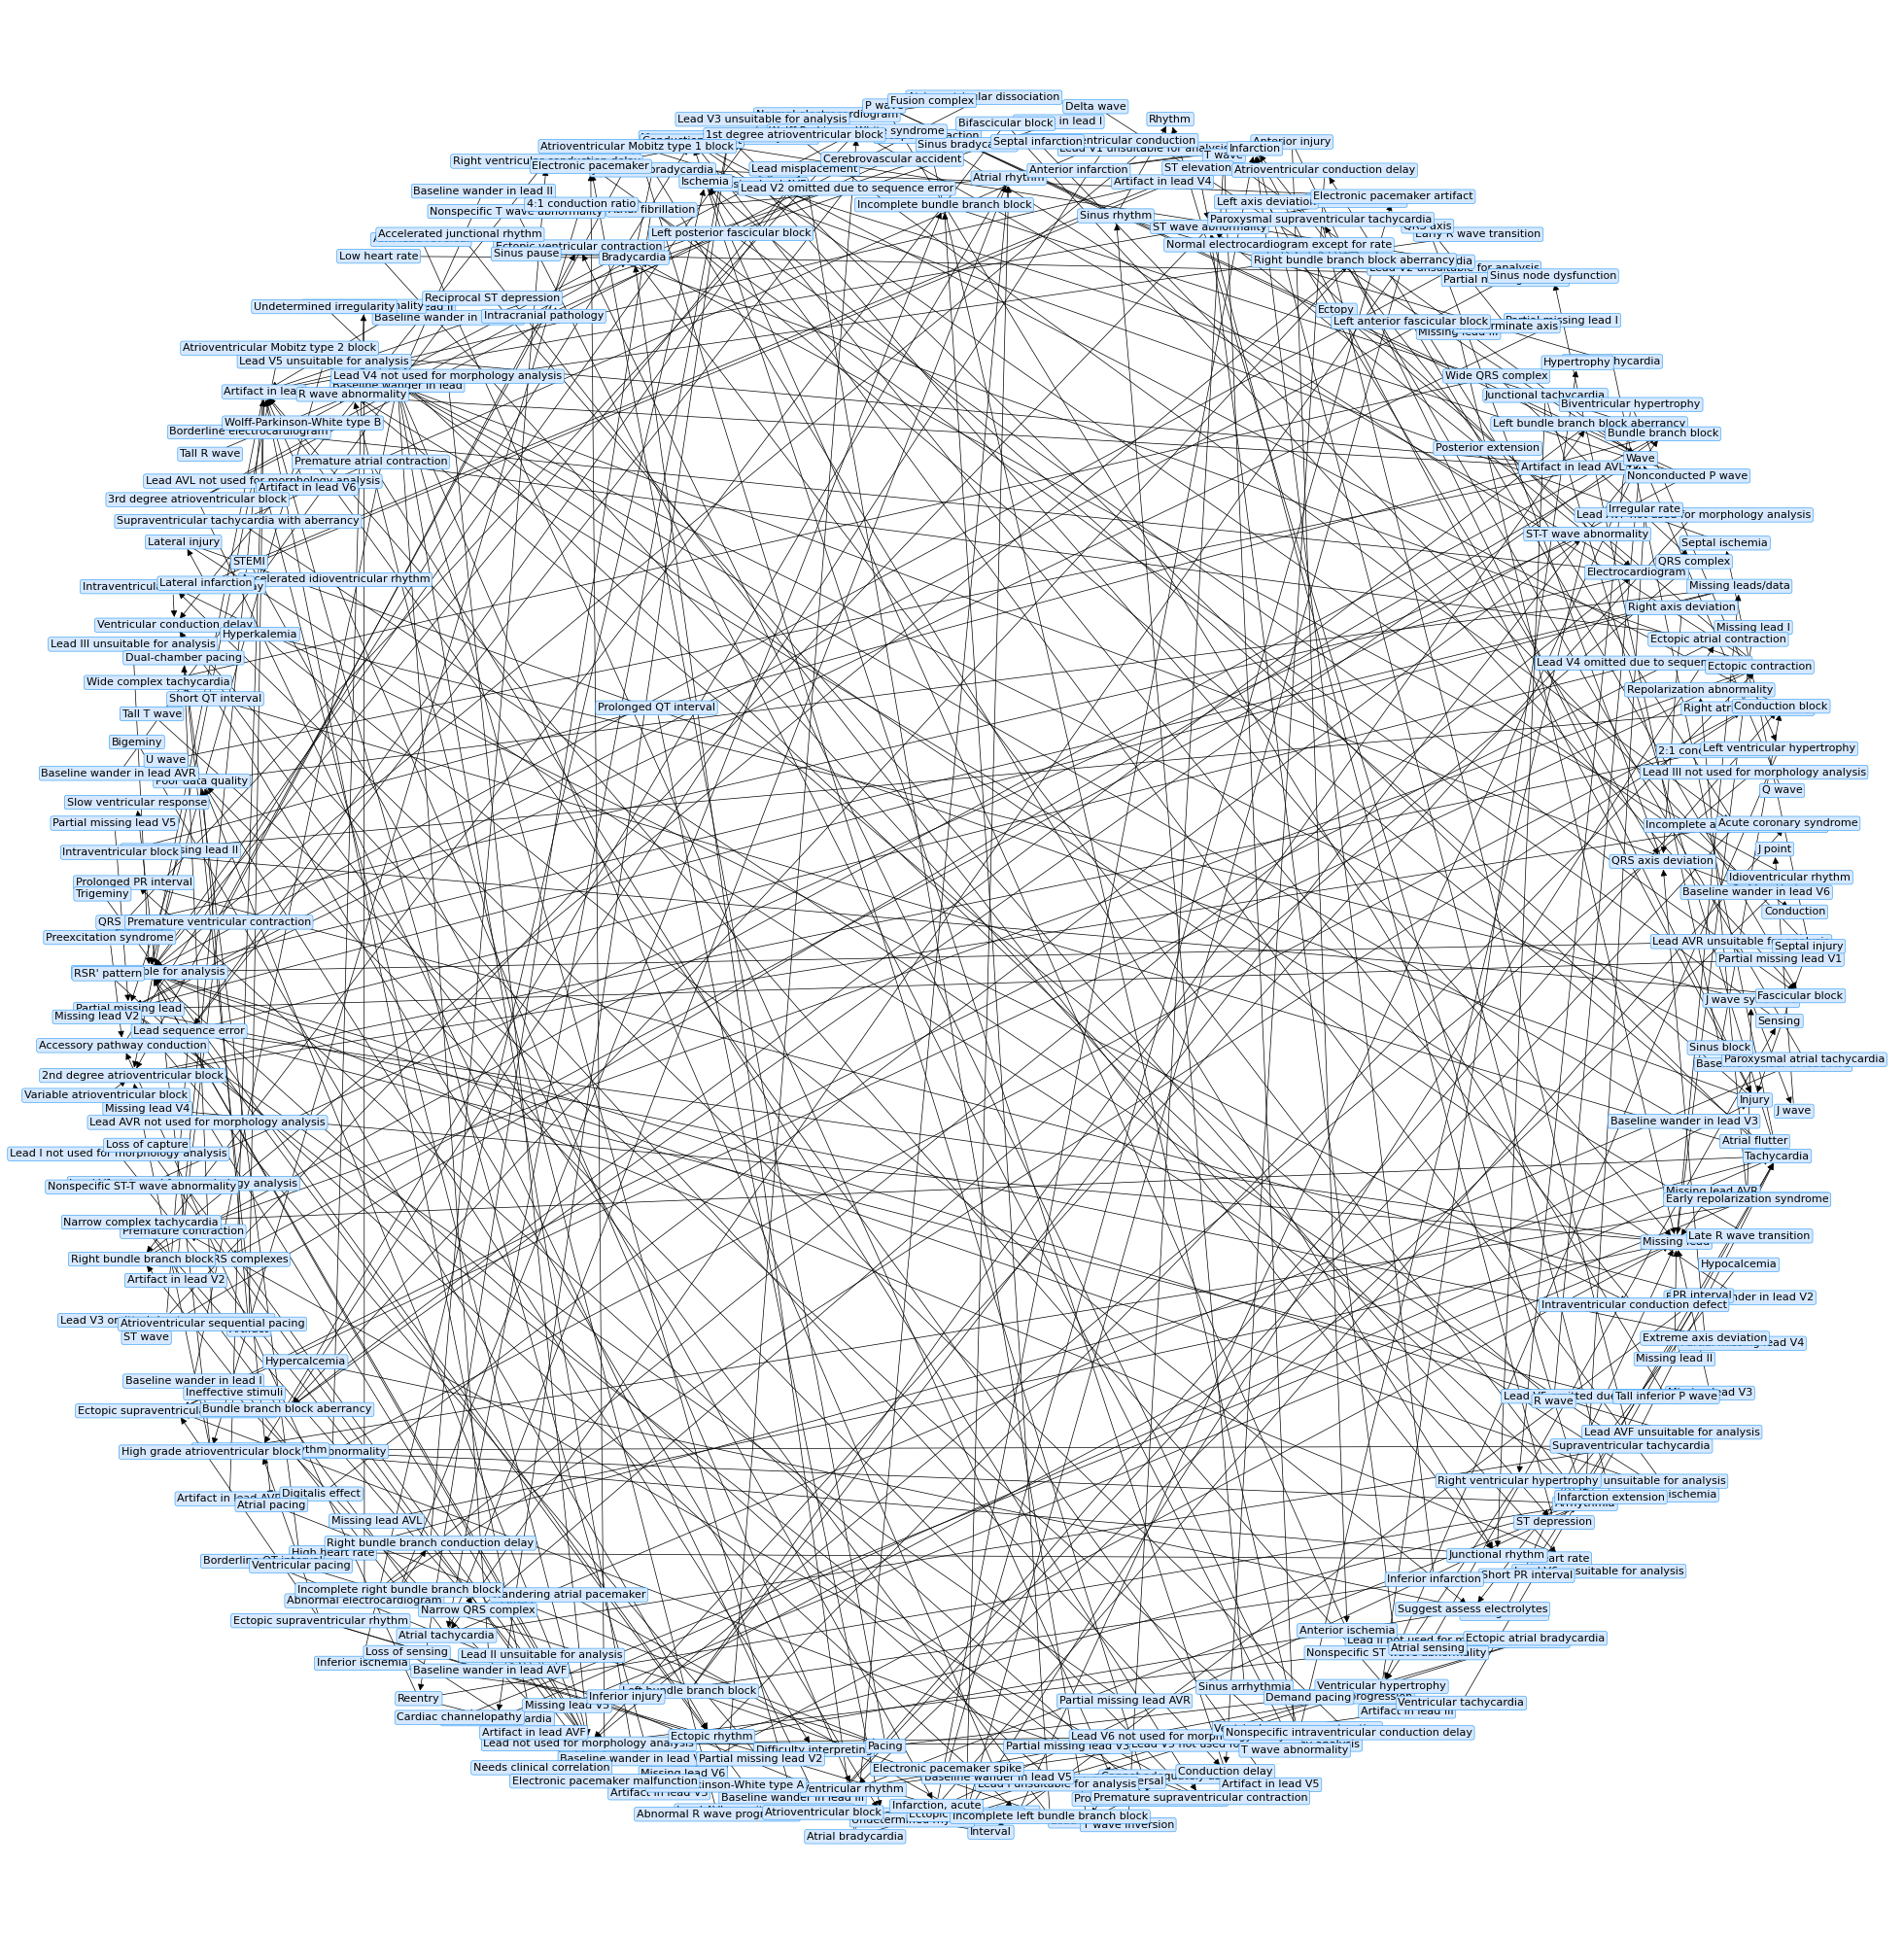

In [ ]:
#PARTIALLY GENERATED CODE
#information from entity_tem.json in knowledge graph (full version)
with open(r"C:\Users\noors\University\thesis\ecg-fm\data\mimic_iv_ecg\labeler\entity_tem.json") as f:
    templates = json.load(f)

edges = []
for entity in templates:
    name = entity["name"]
    sup = entity.get("sup", [])
    if isinstance(sup, str):
        sup = [sup]
    for parent in sup:
        edges.append((name, parent))

G = nx.DiGraph()
G.add_edges_from(edges)

# automatic layout — seed for reproducibility
pos = nx.spring_layout(G, seed=42, k=2.5)

fig, ax = plt.subplots(figsize=(20, 20))

for (child, parent) in G.edges():
    cx, cy = pos[child]
    px, py = pos[parent]
    ax.annotate("",
        xy=(px, py), xytext=(cx, cy),
        arrowprops=dict(
            arrowstyle="-|>",
            color="black",
            lw=0.5,
            shrinkA=6,
            shrinkB=6,
        ))

for node, (x, y) in pos.items():
    text_obj = ax.text(x, y, node, ha="center", va="center",
                       fontsize=8, color="black")
    text_obj.set_bbox(dict(boxstyle="round,pad=0.2",
                           facecolor="#D6E8FF", edgecolor="#2196F3", linewidth=0.4))

ax.axis("off")
all_x = [p[0] for p in pos.values()]
all_y = [p[1] for p in pos.values()]
margin = 0.1
ax.set_xlim(min(all_x) - margin, max(all_x) + margin)
ax.set_ylim(min(all_y) - margin, max(all_y) + margin)
plt.tight_layout()
plt.savefig("kg_full.png", dpi=200, bbox_inches="tight")
plt.show()